# Proyek Analisis Data: [Air Quality Dataset]
- **Nama:** Raihan Okta Rahman
- **Email:** CDCC359D6Y0603@student.devacademy.id
- **ID Dicoding:** CDCC359D6Y0603

## Menentukan Pertanyaan Bisnis

- Stasiun mana yang memiliki rata-rata tahunan PM2.5 tertinggi selama periode 2013–2017?
- Bagaimana pola rata-rata bulanan PM2.5 di stasiun dengan polusi tertinggi selama periode 2013–2017?
- Pada jam berapa konsentrasi PM2.5 tertinggi terjadi dalam sehari di stasiun tersebut selama 2013–2017?
- Bagaimana tren rata-rata tahunan PM2.5, PM10, dan NO2 dari tahun 2013 hingga 2017 di seluruh stasiun?
- Stasiun mana yang menunjukkan penurunan PM2.5 paling signifikan antara tahun 2013 dan 2017?
- Faktor meteorologi mana (suhu, kecepatan angin, tekanan udara) yang memiliki korelasi paling kuat terhadap PM2.5 selama 2013–2017?
- Pada bulan dan jam berapa PM2.5 mencapai level tertinggi sehingga menjadi prioritas waktu intervensi selama periode 2013–2017?

## Import Semua Packages/Library yang Digunakan

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [51]:
!pip install kagglehub[pandas-datasets]

## Data Wrangling

### Gathering Data

In [52]:
import kagglehub
import os

path = kagglehub.dataset_download("sid321axn/beijing-multisite-airquality-data-set")

files = os.listdir(path)
files

Using Colab cache for faster access to the 'beijing-multisite-airquality-data-set' dataset.


['PRSA_Data_Guanyuan_20130301-20170228.csv',
 'PRSA_Data_Aotizhongxin_20130301-20170228.csv',
 'PRSA_Data_Wanliu_20130301-20170228.csv',
 'PRSA_Data_Tiantan_20130301-20170228.csv',
 'PRSA_Data_Wanshouxigong_20130301-20170228.csv',
 'PRSA_Data_Nongzhanguan_20130301-20170228.csv',
 'PRSA_Data_Shunyi_20130301-20170228.csv',
 'PRSA_Data_Changping_20130301-20170228.csv',
 'PRSA_Data_Dingling_20130301-20170228.csv',
 'PRSA_Data_Huairou_20130301-20170228.csv',
 'PRSA_Data_Gucheng_20130301-20170228.csv',
 'PRSA_Data_Dongsi_20130301-20170228.csv']

In [53]:
all_df = {}

for file in files:
    if file.endswith(".csv"):
        station_name = file.split("_")[2]  # ambil nama station

        df = pd.read_csv(os.path.join(path, file))

        all_df[station_name] = df

In [54]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "PRSA_Data_Aotizhongxin_20130301-20170228.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "sid321axn/beijing-multisite-airquality-data-set",
    file_path
)

df.head()

/tmp/ipykernel_4739/3299158811.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'beijing-multisite-airquality-data-set' dataset.


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [55]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "PRSA_Data_Changping_20130301-20170228.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "sid321axn/beijing-multisite-airquality-data-set",
    file_path
)

df.head()

/tmp/ipykernel_4739/3944756711.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'beijing-multisite-airquality-data-set' dataset.


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


In [56]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "PRSA_Data_Dingling_20130301-20170228.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "sid321axn/beijing-multisite-airquality-data-set",
    file_path
)

df.head()

/tmp/ipykernel_4739/1441222491.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'beijing-multisite-airquality-data-set' dataset.


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling


In [57]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "PRSA_Data_Dongsi_20130301-20170228.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "sid321axn/beijing-multisite-airquality-data-set",
    file_path
)

df.head()

/tmp/ipykernel_4739/2833480528.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'beijing-multisite-airquality-data-set' dataset.


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


In [58]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "PRSA_Data_Guanyuan_20130301-20170228.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "sid321axn/beijing-multisite-airquality-data-set",
    file_path
)

df.head()

/tmp/ipykernel_4739/3689608923.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'beijing-multisite-airquality-data-set' dataset.


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan


In [59]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "PRSA_Data_Gucheng_20130301-20170228.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "sid321axn/beijing-multisite-airquality-data-set",
    file_path
)

df.head()

/tmp/ipykernel_4739/1762016683.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'beijing-multisite-airquality-data-set' dataset.


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng


In [60]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "PRSA_Data_Huairou_20130301-20170228.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "sid321axn/beijing-multisite-airquality-data-set",
    file_path
)

df.head()

/tmp/ipykernel_4739/2695516032.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'beijing-multisite-airquality-data-set' dataset.


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
1,2,2013,3,1,1,4.0,4.0,3.0,NaN,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou
2,3,2013,3,1,2,4.0,4.0,NaN,NaN,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,NaN,NaN,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou


In [61]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "PRSA_Data_Huairou_20130301-20170228.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "sid321axn/beijing-multisite-airquality-data-set",
    file_path
)

df.head()

/tmp/ipykernel_4739/2695516032.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'beijing-multisite-airquality-data-set' dataset.


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
1,2,2013,3,1,1,4.0,4.0,3.0,NaN,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou
2,3,2013,3,1,2,4.0,4.0,NaN,NaN,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,NaN,NaN,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou


In [62]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "PRSA_Data_Nongzhanguan_20130301-20170228.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "sid321axn/beijing-multisite-airquality-data-set",
    file_path
)

df.head()

/tmp/ipykernel_4739/357985986.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'beijing-multisite-airquality-data-set' dataset.


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,3,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan
3,4,2013,3,1,3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan
4,5,2013,3,1,4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan


In [63]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "PRSA_Data_Shunyi_20130301-20170228.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "sid321axn/beijing-multisite-airquality-data-set",
    file_path
)

df.head()

/tmp/ipykernel_4739/3979647729.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'beijing-multisite-airquality-data-set' dataset.


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi
1,2,2013,3,1,1,12.0,12.0,3.0,7.0,300.0,47.0,-1.1,1026.1,-21.3,0.0,NW,9.4,Shunyi
2,3,2013,3,1,2,14.0,14.0,NaN,7.0,200.0,22.0,-1.7,1026.2,-23.0,0.0,NW,8.6,Shunyi
3,4,2013,3,1,3,12.0,12.0,3.0,5.0,NaN,NaN,-2.1,1027.3,-23.3,0.0,NW,6.6,Shunyi
4,5,2013,3,1,4,12.0,12.0,3.0,NaN,200.0,11.0,-2.4,1027.7,-22.9,0.0,NW,4.5,Shunyi


In [64]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "PRSA_Data_Tiantan_20130301-20170228.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "sid321axn/beijing-multisite-airquality-data-set",
    file_path
)

df.head()

/tmp/ipykernel_4739/1409561740.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'beijing-multisite-airquality-data-set' dataset.


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan
1,2,2013,3,1,1,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Tiantan
2,3,2013,3,1,2,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Tiantan
3,4,2013,3,1,3,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,N,4.9,Tiantan
4,5,2013,3,1,4,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Tiantan


In [65]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "PRSA_Data_Wanliu_20130301-20170228.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "sid321axn/beijing-multisite-airquality-data-set",
    file_path
)

df.head()

/tmp/ipykernel_4739/985930160.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'beijing-multisite-airquality-data-set' dataset.


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,8.0,8.0,6.0,28.0,400.0,52.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Wanliu
1,2,2013,3,1,1,9.0,9.0,6.0,28.0,400.0,50.0,-1.1,1023.2,-18.2,0.0,N,4.7,Wanliu
2,3,2013,3,1,2,3.0,6.0,NaN,19.0,400.0,55.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Wanliu
3,4,2013,3,1,3,11.0,30.0,8.0,14.0,NaN,NaN,-1.4,1024.5,-19.4,0.0,NW,3.1,Wanliu
4,5,2013,3,1,4,3.0,13.0,9.0,NaN,300.0,54.0,-2.0,1025.2,-19.5,0.0,N,2.0,Wanliu


In [66]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "PRSA_Data_Wanshouxigong_20130301-20170228.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "sid321axn/beijing-multisite-airquality-data-set",
    file_path
)

df.head()

/tmp/ipykernel_4739/748574969.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'beijing-multisite-airquality-data-set' dataset.


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong
1,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong
2,3,2013,3,1,2,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,WNW,4.7,Wanshouxigong
3,4,2013,3,1,3,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,NW,2.6,Wanshouxigong
4,5,2013,3,1,4,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,WNW,2.5,Wanshouxigong


**Insights:**
*   Fungsi pembacaan data berhasil memetakan setiap variabel ke dalam kolom yang tepat. Struktur data sudah berbentuk tabular (baris dan kolom) yang rapi, di mana setiap kolom memiliki header yang jelas tanpa adanya pergeseran nilai akibat kesalahan delimiter.
*   Secara visual, kolom polutan (`PM2.5`, `PM10`, `SO2`, dll.) dan parameter cuaca (`TEMP`, `PRES`, `DEWP`) berisi nilai numerik (float/integer) yang bersih. Tidak terlihat adanya simbol satuan atau karakter non-numerik di dalam sel tersebut, sehingga data siap digunakan untuk perhitungan statistik atau pemodelan tanpa perlu pembersihan karakter string tambahan.






### Assessing Data

In [67]:
for station, df in all_df.items():
    print(f"\n{'='*20} {station} {'='*20}")

    print("1. Info Data:")
    df.info()

    print("\n2. Missing Values:")
    print(df.isna().sum())

    print("\n3. Statistik:")
    display(df.describe())


==================== Guanyuan ====================
1. Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34448 non-null  float64
 6   PM10     34635 non-null  float64
 7   SO2      34590 non-null  float64
 8   NO2      34405 non-null  float64
 9   CO       33311 non-null  float64
 10  O3       33891 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB

2

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34448.000000,34635.000000,34590.000000,34405.000000,33311.000000,33891.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.933372,109.023303,17.590941,57.901643,1271.294377,55.795044,13.584607,1011.846920,3.123062,0.067421,1.708496
std,10122.249256,1.177213,3.448752,8.800218,6.922285,80.933497,91.573709,23.600367,35.150857,1164.854945,57.436983,11.399097,10.404047,13.688896,0.910056,1.204071
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,1.000000,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,40.000000,3.000000,31.000000,500.000000,7.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,89.000000,8.000000,51.000000,900.000000,41.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,115.000000,149.000000,22.000000,78.000000,1600.000000,81.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,680.000000,999.000000,293.000000,270.000000,10000.000000,415.000000,40.500000,1042.000000,28.500000,72.500000,11.200000



==================== Aotizhongxin ====================
1. Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ M

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34139.000000,34346.000000,34129.000000,34041.000000,33288.000000,33345.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.773611,110.060391,17.375901,59.305833,1262.945145,56.353358,13.584607,1011.846920,3.123062,0.067421,1.708496
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.135694,95.223005,22.823017,37.116200,1221.436236,57.916327,11.399097,10.404047,13.688896,0.910056,1.204071
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,30.000000,500.000000,8.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,58.000000,87.000000,9.000000,53.000000,900.000000,42.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,114.000000,155.000000,21.000000,82.000000,1500.000000,82.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,898.000000,984.000000,341.000000,290.000000,10000.000000,423.000000,40.500000,1042.000000,28.500000,72.500000,11.200000



==================== Wanliu ====================
1. Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34682 non-null  float64
 6   PM10     34780 non-null  float64
 7   SO2      34489 non-null  float64
 8   NO2      33994 non-null  float64
 9   CO       33252 non-null  float64
 10  O3       32957 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34941 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB

2. 

...

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34111.000000,34287.000000,34084.000000,33425.000000,33642.000000,33913.000000,35013.000000,35011.000000,35011.000000,35009.000000,35015.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,69.626367,91.482690,12.121553,32.497250,1022.554545,59.824713,12.445426,1007.598568,2.238619,0.067940,1.652021
std,10122.249256,1.177213,3.448752,8.800218,6.922285,71.224916,83.289578,18.896912,26.489531,898.738241,54.605746,11.751103,10.022101,14.052541,0.849046,1.199143
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.800000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,17.000000,28.000000,2.000000,12.000000,400.000000,18.000000,2.100000,999.300000,-9.600000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,47.000000,69.000000,4.000000,25.000000,800.000000,49.000000,13.600000,1007.300000,2.700000,0.000000,1.300000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,98.000000,131.000000,14.000000,46.000000,1300.000000,83.000000,22.300000,1015.500000,15.300000,0.000000,2.000000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,762.000000,993.000000,315.000000,231.000000,10000.000000,444.000000,40.300000,1036.500000,29.100000,45.900000,12.900000



==================== Gucheng ====================
1. Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34418 non-null  float64
 6   PM10     34683 non-null  float64
 7   SO2      34557 non-null  float64
 8   NO2      34396 non-null  float64
 9   CO       33663 non-null  float64
 10  O3       34335 non-null  float64
 11  TEMP     35013 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35013 non-null  float64
 14  RAIN     35021 non-null  float64
 15  wd       34905 non-null  object 
 16  WSPM     35022 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB

2.

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34418.000000,34683.000000,34557.000000,34396.000000,33663.000000,34335.000000,35013.000000,35014.000000,35013.000000,35021.000000,35022.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,83.852089,118.861978,15.366162,55.871075,1323.974423,57.694879,13.864524,1008.829592,2.610442,0.064453,1.343310
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.796445,96.742626,21.204526,36.473860,1208.957772,57.019587,11.292857,10.103256,13.782991,0.838654,1.151064
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-15.600000,984.000000,-34.600000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,24.000000,45.000000,2.000000,26.000000,600.000000,10.000000,3.600000,1000.500000,-8.900000,0.000000,0.600000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,60.000000,99.000000,7.000000,50.000000,900.000000,45.000000,14.800000,1008.500000,3.000000,0.000000,1.000000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,115.750000,167.000000,20.000000,79.000000,1600.000000,83.000000,23.500000,1017.000000,15.300000,0.000000,1.800000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,770.000000,994.000000,500.000000,276.000000,10000.000000,450.000000,41.600000,1038.100000,27.400000,41.900000,12.000000



==================== Dongsi ====================
1. Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34314 non-null  float64
 6   PM10     34511 non-null  float64
 7   SO2      34401 non-null  float64
 8   NO2      33463 non-null  float64
 9   CO       31867 non-null  float64
 10  O3       34400 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB

2. 

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34314.000000,34511.000000,34401.000000,33463.000000,31867.000000,34400.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,86.194297,110.336742,18.531107,53.699443,1330.069131,57.210637,13.671490,1012.547419,2.447535,0.064020,1.860785
std,10122.249256,1.177213,3.448752,8.800218,6.922285,86.575127,98.219860,22.905655,33.959230,1191.305887,58.033275,11.458418,10.266059,13.810696,0.786282,1.280368
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.642600,-16.800000,987.100000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,4.000000,27.000000,600.000000,12.000000,3.100000,1004.000000,-8.800000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,61.000000,86.000000,10.000000,47.000000,1000.000000,44.125200,14.600000,1012.200000,3.000000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,119.000000,151.000000,24.000000,73.000000,1700.000000,81.000000,23.500000,1020.900000,15.000000,0.000000,2.400000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,737.000000,955.000000,300.000000,258.000000,10000.000000,1071.000000,41.100000,1042.000000,28.800000,46.400000,10.500000


In [68]:
for station, df in all_df.items():
    print(f"\n{'='*20} {station} {'='*20}")

    # Format Waktu
    print("\n4. Cek & Buat Kolom Datetime:")
    try:
        df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
        print("Kolom datetime berhasil dibuat")
    except:
        print("Kolom datetime gagal dibuat")

    # Statistik Polutan (Outlier check kasar)
    print("\n5. Statistik Polutan:")
    display(df[['PM2.5','PM10','NO2','SO2','CO','O3']].describe())

    # Statistik Meteorologi
    print("\n6. Statistik Meteorologi:")
    display(df[['TEMP','PRES','DEWP','RAIN','WSPM']].describe())

    # Konsistensi Kategori (Wind Direction)
    print("\n7. Wind Direction Unik:")
    print(df['wd'].unique())


==================== Guanyuan ====================

4. Cek & Buat Kolom Datetime:
Kolom datetime berhasil dibuat

5. Statistik Polutan:


,PM2.5,PM10,NO2,SO2,CO,O3
count,34448.000000,34635.000000,34405.000000,34590.000000,33311.000000,33891.000000
mean,82.933372,109.023303,57.901643,17.590941,1271.294377,55.795044
std,80.933497,91.573709,35.150857,23.600367,1164.854945,57.436983
min,2.000000,2.000000,2.000000,1.000000,100.000000,0.214200
25%,23.000000,40.000000,31.000000,3.000000,500.000000,7.000000
50%,59.000000,89.000000,51.000000,8.000000,900.000000,41.000000
75%,115.000000,149.000000,78.000000,22.000000,1600.000000,81.000000
max,680.000000,999.000000,270.000000,293.000000,10000.000000,415.000000



6. Statistik Meteorologi:


,TEMP,PRES,DEWP,RAIN,WSPM
count,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,13.584607,1011.846920,3.123062,0.067421,1.708496
std,11.399097,10.404047,13.688896,0.910056,1.204071
min,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,23.300000,1020.100000,15.600000,0.000000,2.200000
max,40.500000,1042.000000,28.500000,72.500000,11.200000



7. Wind Direction Unik:
['NNW' 'N' 'NW' 'NNE' 'ENE' 'E' 'NE' 'W' 'SSW' 'WSW' 'SE' 'WNW' 'SSE'
 'ESE' 'S' 'SW' nan]

==================== Aotizhongxin ====================

4. Cek & Buat Kolom Datetime:
Kolom datetime berhasil dibuat

5. Statistik Polutan:


...


7. Wind Direction Unik:
['NW' 'WNW' 'W' 'E' 'ENE' 'NE' 'ESE' 'SSE' 'NNE' 'SW' 'SSW' 'S' 'SE' 'NNW'
 'N' 'WSW' nan]

==================== Dongsi ====================

4. Cek & Buat Kolom Datetime:
Kolom datetime berhasil dibuat

5. Statistik Polutan:


,PM2.5,PM10,NO2,SO2,CO,O3
count,34314.000000,34511.000000,33463.000000,34401.000000,31867.000000,34400.000000
mean,86.194297,110.336742,53.699443,18.531107,1330.069131,57.210637
std,86.575127,98.219860,33.959230,22.905655,1191.305887,58.033275
min,3.000000,2.000000,2.000000,0.285600,100.000000,0.642600
25%,22.000000,38.000000,27.000000,4.000000,600.000000,12.000000
50%,61.000000,86.000000,47.000000,10.000000,1000.000000,44.125200
75%,119.000000,151.000000,73.000000,24.000000,1700.000000,81.000000
max,737.000000,955.000000,258.000000,300.000000,10000.000000,1071.000000



6. Statistik Meteorologi:


,TEMP,PRES,DEWP,RAIN,WSPM
count,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,13.671490,1012.547419,2.447535,0.064020,1.860785
std,11.458418,10.266059,13.810696,0.786282,1.280368
min,-16.800000,987.100000,-35.300000,0.000000,0.000000
25%,3.100000,1004.000000,-8.800000,0.000000,1.000000
50%,14.600000,1012.200000,3.000000,0.000000,1.500000
75%,23.500000,1020.900000,15.000000,0.000000,2.400000
max,41.100000,1042.000000,28.800000,46.400000,10.500000



7. Wind Direction Unik:
['NNW' 'NW' 'N' 'W' 'ENE' 'NE' 'E' 'NNE' 'SW' 'SSW' 'S' 'WSW' 'ESE' 'SE'
 'WNW' 'SSE' nan]


### Cleaning Data

In [69]:
cleaned_df = {}

for station, df in all_df.items():
    print(f"\nCleaning data: {station}")

    # Copy data agar data asli aman
    df = df.copy()

    # Drop kolom tidak perlu
    if 'No' in df.columns:
        df.drop(columns=['No'], inplace=True)

    # Buat kolom datetime
    df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

    # Hapus duplikat
    df = df.drop_duplicates()

    # Handle missing values (numerik → interpolasi)
    num_cols = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']

    for col in num_cols:
        if col in df.columns:
            df[col] = df[col].interpolate(method='linear')

    # Isi sisa missing (jika masih ada)
    df[num_cols] = df[num_cols].fillna(method='bfill').fillna(method='ffill')

    # Handle outlier (hapus nilai negatif)
    for col in ['PM2.5','PM10','SO2','NO2','CO','O3']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: x if x >= 0 else np.nan)

    # clip nilai ekstrem (biar lebih realistis)
    for col in ['PM2.5','PM10','SO2','NO2','CO','O3']:
        if col in df.columns:
            df[col] = df[col].clip(lower=0, upper=df[col].quantile(0.99))

    # Reset index
    df.reset_index(drop=True, inplace=True)

    # Simpan hasil
    cleaned_df[station] = df

    print(f"Done: {station} | Shape: {df.shape}")


Cleaning data: Guanyuan
Done: Guanyuan | Shape: (35064, 18)

Cleaning data: Aotizhongxin
Done: Aotizhongxin | Shape: (35064, 18)

Cleaning data: Wanliu


/tmp/ipykernel_4739/784612241.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[num_cols] = df[num_cols].fillna(method='bfill').fillna(method='ffill')
/tmp/ipykernel_4739/784612241.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[num_cols] = df[num_cols].fillna(method='bfill').fillna(method='ffill')
/tmp/ipykernel_4739/784612241.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[num_cols] = df[num_cols].fillna(method='bfill').fillna(method='ffill')


Done: Wanliu | Shape: (35064, 18)

Cleaning data: Tiantan
Done: Tiantan | Shape: (35064, 18)

Cleaning data: Wanshouxigong
Done: Wanshouxigong | Shape: (35064, 18)

Cleaning data: Nongzhanguan


/tmp/ipykernel_4739/784612241.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[num_cols] = df[num_cols].fillna(method='bfill').fillna(method='ffill')
/tmp/ipykernel_4739/784612241.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[num_cols] = df[num_cols].fillna(method='bfill').fillna(method='ffill')
/tmp/ipykernel_4739/784612241.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[num_cols] = df[num_cols].fillna(method='bfill').fillna(method='ffill')


Done: Nongzhanguan | Shape: (35064, 18)

Cleaning data: Shunyi


...

/tmp/ipykernel_4739/784612241.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[num_cols] = df[num_cols].fillna(method='bfill').fillna(method='ffill')


Done: Dingling | Shape: (35064, 18)

Cleaning data: Huairou
Done: Huairou | Shape: (35064, 18)

Cleaning data: Gucheng


/tmp/ipykernel_4739/784612241.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[num_cols] = df[num_cols].fillna(method='bfill').fillna(method='ffill')
/tmp/ipykernel_4739/784612241.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[num_cols] = df[num_cols].fillna(method='bfill').fillna(method='ffill')


Done: Gucheng | Shape: (35064, 18)

Cleaning data: Dongsi
Done: Dongsi | Shape: (35064, 18)


/tmp/ipykernel_4739/784612241.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[num_cols] = df[num_cols].fillna(method='bfill').fillna(method='ffill')


In [70]:
for station, df in cleaned_df.items():
    print(f"{station} → missing: {df.isna().sum().sum()}, duplikat: {df.duplicated().sum()}")

Guanyuan → missing: 81, duplikat: 0
Aotizhongxin → missing: 81, duplikat: 0
Wanliu → missing: 123, duplikat: 0
Tiantan → missing: 78, duplikat: 0
Wanshouxigong → missing: 79, duplikat: 0
Nongzhanguan → missing: 78, duplikat: 0
Shunyi → missing: 483, duplikat: 0
Changping → missing: 140, duplikat: 0
Dingling → missing: 140, duplikat: 0
Huairou → missing: 302, duplikat: 0
Gucheng → missing: 159, duplikat: 0
Dongsi → missing: 78, duplikat: 0


In [80]:
df['wd'] = df['wd'].ffill().bfill()

In [82]:
for station, df in cleaned_df.items():
    print(f"{station} → missing wd: {df['wd'].isna().sum()}")

Guanyuan → missing wd: 81
Aotizhongxin → missing wd: 81
Wanliu → missing wd: 123
Tiantan → missing wd: 78
Wanshouxigong → missing wd: 79
Nongzhanguan → missing wd: 78
Shunyi → missing wd: 483
Changping → missing wd: 140
Dingling → missing wd: 140
Huairou → missing wd: 302
Gucheng → missing wd: 159
Dongsi → missing wd: 0


In [89]:
for station, df in cleaned_df.items():
    print(f"\n{station}")
    print(df['wd'].unique()[:10])


Guanyuan
['NNW' 'N' 'NW' 'NNE' 'ENE' 'E' 'NE' 'W' 'SSW' 'WSW']

Aotizhongxin
['NNW' 'N' 'NW' 'NNE' 'ENE' 'E' 'NE' 'W' 'SSW' 'WSW']

Wanliu
['NNW' 'N' 'NW' 'NNE' 'ENE' 'E' 'NE' 'W' 'SSW' 'WSW']

Tiantan
['NNW' 'NW' 'N' 'W' 'ENE' 'NE' 'E' 'NNE' 'SW' 'SSW']

Wanshouxigong
['WNW' 'NW' 'NE' 'NNE' 'ENE' 'N' 'ESE' 'NNW' 'E' 'WSW']

Nongzhanguan
['NNW' 'NW' 'N' 'W' 'ENE' 'NE' 'E' 'NNE' 'SW' 'SSW']

Shunyi
['NW' 'NNW' 'NNE' 'NE' 'SSW' 'ENE' 'N' 'E' 'SW' 'WNW']

Changping
['E' 'ENE' 'NNE' 'N' 'NNW' 'NW' 'NE' 'SW' 'SSW' 'WSW']

Dingling
['E' 'ENE' 'NNE' 'N' 'NNW' 'NW' 'NE' 'SW' 'SSW' 'WSW']

Huairou
['WNW' 'NNW' 'NW' 'N' 'NNE' 'NE' 'ESE' 'SE' 'W' 'S']

Gucheng
['NW' 'WNW' 'W' 'E' 'ENE' 'NE' 'ESE' 'SSE' 'NNE' 'SW']

Dongsi
['NNW' 'NW' 'N' 'W' 'ENE' 'NE' 'E' 'NNE' 'SW' 'SSW']


In [91]:
for station, df in cleaned_df.items():


    df['wd'] = df['wd'].ffill().bfill()


    if df['wd'].isna().sum() > 0:
        mode_wd = df['wd'].mode()[0]
        df['wd'] = df['wd'].fillna(mode_wd)

    cleaned_df[station] = df

In [92]:
for station, df in cleaned_df.items():
    print(f"{station} → missing wd:", df['wd'].isna().sum())

Guanyuan → missing wd: 0
Aotizhongxin → missing wd: 0
Wanliu → missing wd: 0
Tiantan → missing wd: 0
Wanshouxigong → missing wd: 0
Nongzhanguan → missing wd: 0
Shunyi → missing wd: 0
Changping → missing wd: 0
Dingling → missing wd: 0
Huairou → missing wd: 0
Gucheng → missing wd: 0
Dongsi → missing wd: 0


### Menggambungkan Data Stasiun Beijing

In [93]:
for station, df in cleaned_df.items():
    df['station'] = station

In [94]:
df_final = pd.concat(cleaned_df.values(), ignore_index=True)

In [95]:
df_final.head()
df_final.head()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan,2013-03-01 00:00:00
1,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan,2013-03-01 01:00:00
2,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan,2013-03-01 02:00:00
3,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan,2013-03-01 03:00:00
4,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan,2013-03-01 04:00:00


In [96]:
df_final.to_csv("main_data.csv", index=False)

## Exploratory Data Analysis (EDA)

### OVERVIEW DATA

In [97]:
df_final.head()
df_final.shape
df_final.columns

Index(['year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO',
       'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station',
       'datetime'],
      dtype='object')

### Explore Distribusi Polutan

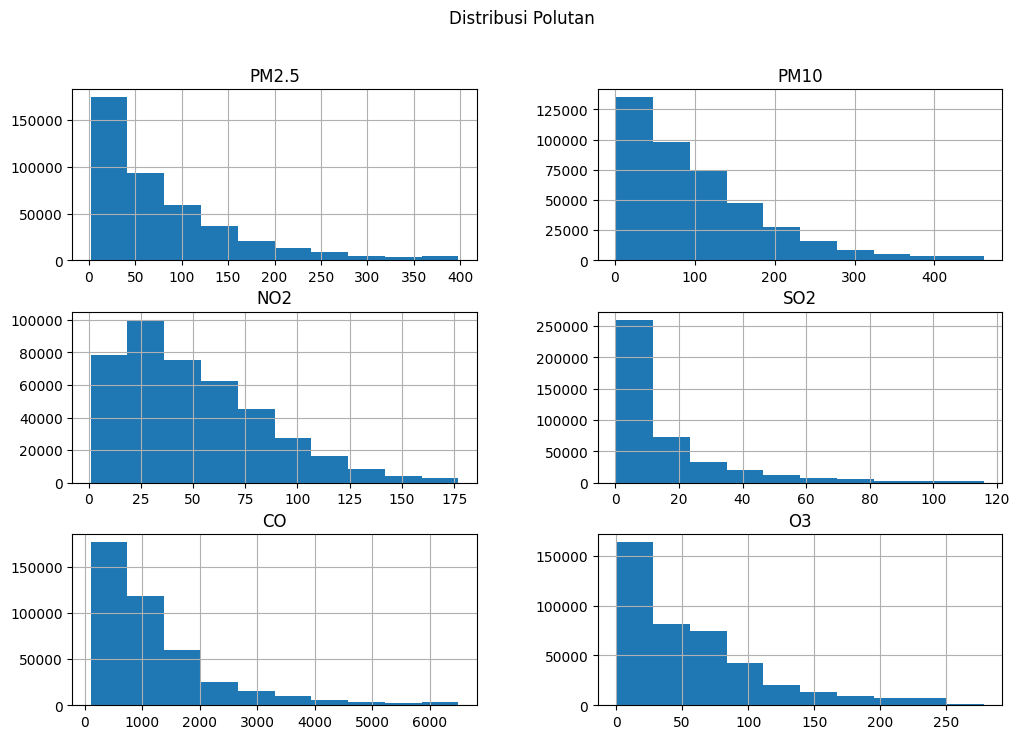

In [98]:
cols = ['PM2.5','PM10','NO2','SO2','CO','O3']

df_final[cols].hist(figsize=(12,8))
plt.suptitle("Distribusi Polutan")
plt.show()

### Explore Perbandingan Per Station

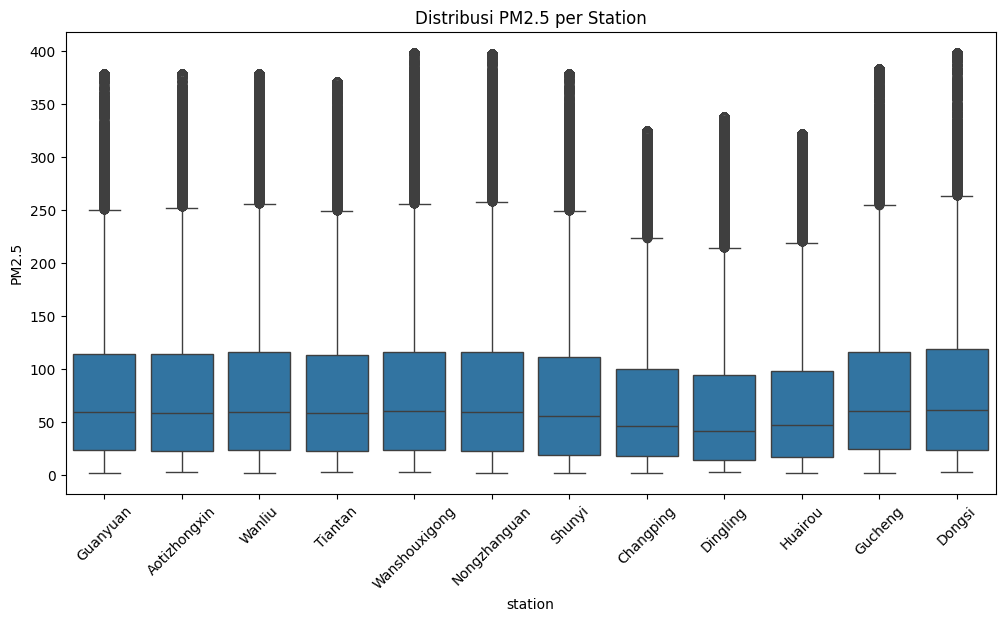

In [99]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_final, x='station', y='PM2.5')
plt.xticks(rotation=45)
plt.title("Distribusi PM2.5 per Station")
plt.show()

### Explore Tren Waktu Global

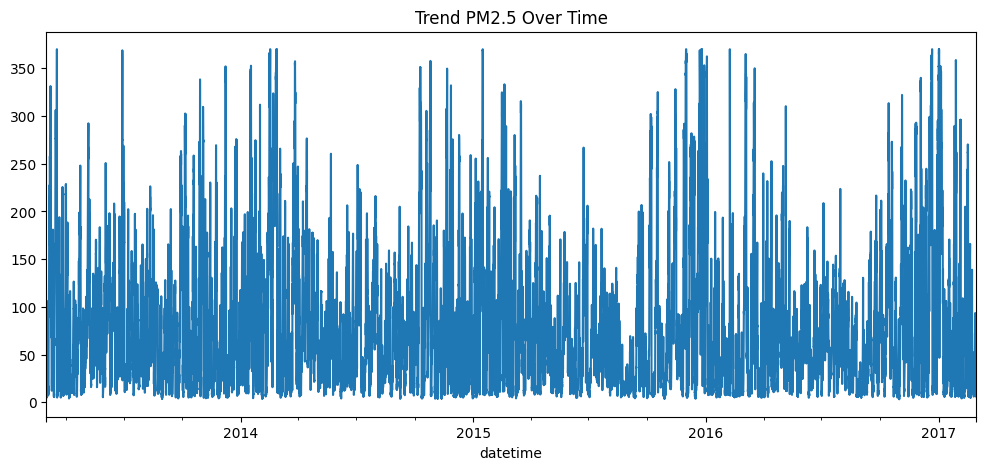

In [100]:
time_series = df_final.groupby('datetime')['PM2.5'].mean()

plt.figure(figsize=(12,5))
time_series.plot()
plt.title("Trend PM2.5 Over Time")
plt.show()

### Explore Pola Harian

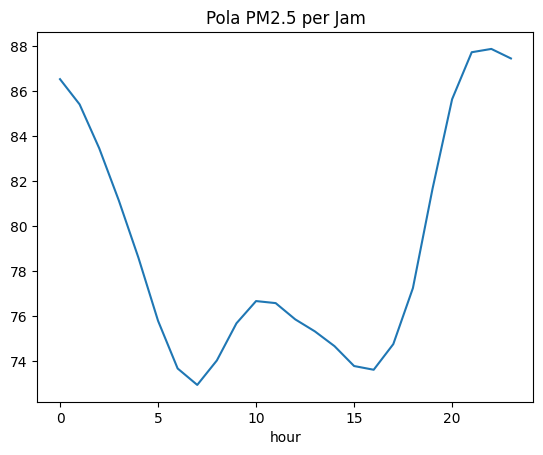

In [101]:
hourly = df_final.groupby('hour')['PM2.5'].mean()

hourly.plot(title="Pola PM2.5 per Jam")
plt.show()

### Explore Pola Bulanan

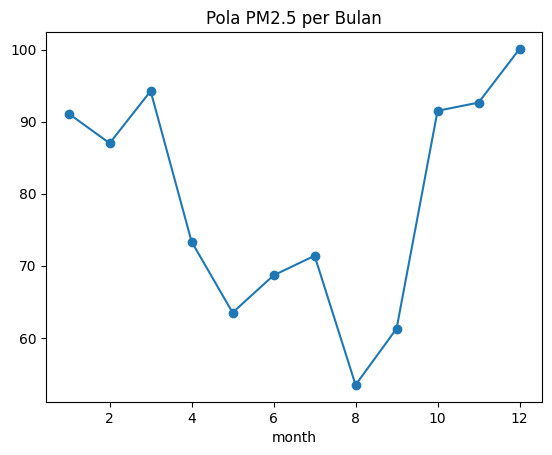

In [102]:
monthly = df_final.groupby('month')['PM2.5'].mean()

monthly.plot(marker='o', title="Pola PM2.5 per Bulan")
plt.show()

### Explore Hubungan Dengan Cuaca

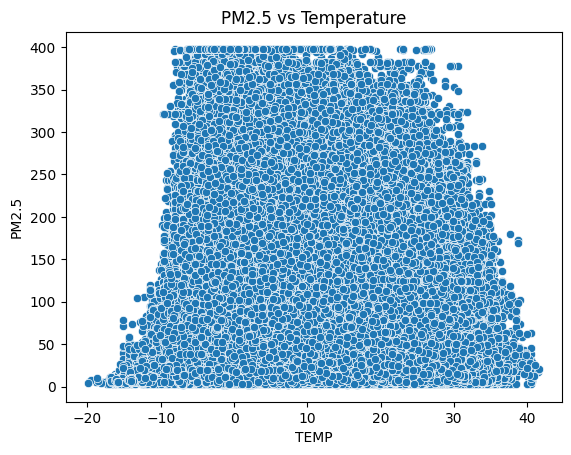

In [103]:
sns.scatterplot(data=df_final, x='TEMP', y='PM2.5')
plt.title("PM2.5 vs Temperature")
plt.show()

### Explore Korelasi

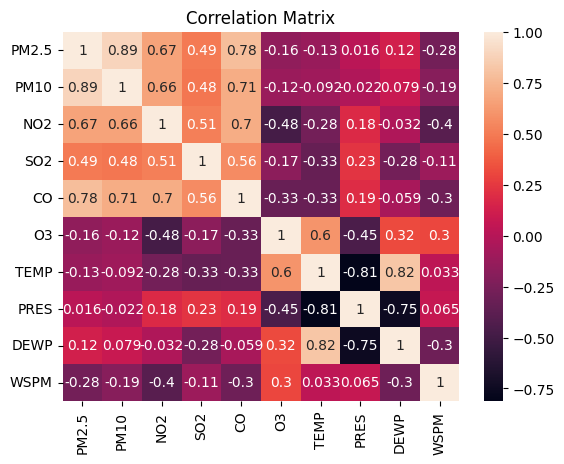

In [104]:
corr = df_final[['PM2.5','PM10','NO2','SO2','CO','O3','TEMP','PRES','DEWP','WSPM']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

## Visualization & Explanatory Analysis

### Pertanyaan 1: Stasiun mana yang memiliki rata-rata tahunan PM2.5 tertinggi selama periode 2013–2017?

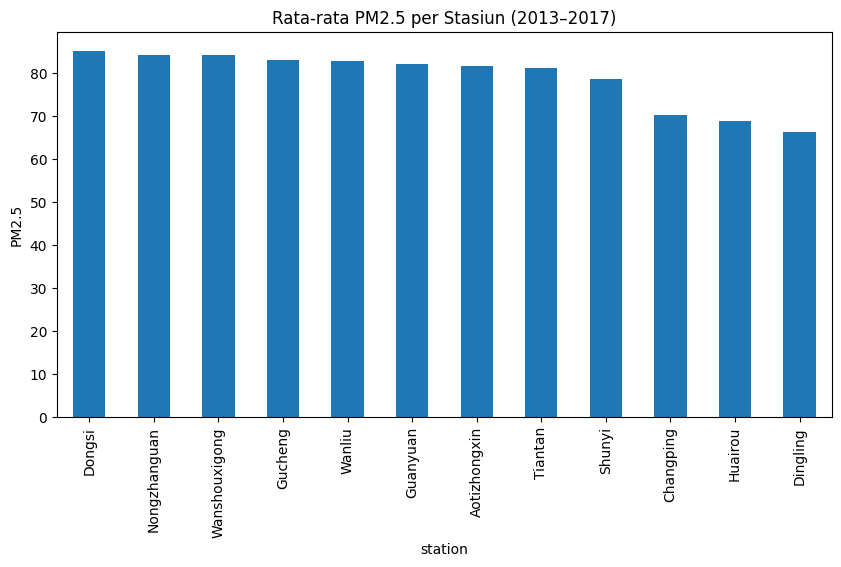

In [105]:
station_pm25 = df_final.groupby('station')['PM2.5'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
station_pm25.plot(kind='bar')
plt.title("Rata-rata PM2.5 per Stasiun (2013–2017)")
plt.ylabel("PM2.5")
plt.show()

**Insights:**
- **Dongsi** mencatat rata-rata PM2.5 tertinggi selama 2013–2017, menunjukkan tingkat polusi paling tinggi dibanding stasiun lain.
- Sebagian besar stasiun berada pada kisaran PM2.5 yang relatif mirip (80–85), menandakan distribusi polusi cukup merata.
- ***Dingling, Huairou, dan Changping*** memiliki nilai terendah, mengindikasikan kualitas udara yang relatif lebih baik.

### Pertanyaan 2: Bagaimana pola rata-rata bulanan PM2.5 di stasiun dengan polusi tertinggi selama periode 2013–2017?

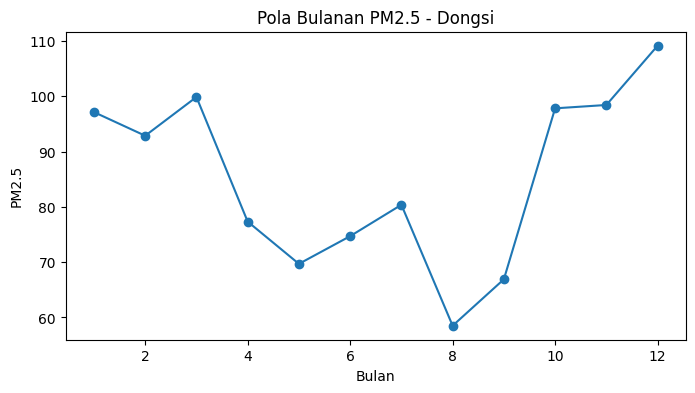

In [106]:
top_station = station_pm25.idxmax()

monthly = df_final[df_final['station']==top_station].groupby('month')['PM2.5'].mean()

plt.figure(figsize=(8,4))
monthly.plot(marker='o')
plt.title(f"Pola Bulanan PM2.5 - {top_station}")
plt.xlabel("Bulan")
plt.ylabel("PM2.5")
plt.show()

**Insights:**
- PM2.5 di Dongsi menunjukkan pola musiman jelas, tinggi di awal & akhir tahun dan rendah di pertengahan tahun.
- Puncak polusi terjadi pada bulan 12 (109), sementara terendah di bulan 8 (58).
- Pola ini mengindikasikan polusi meningkat saat musim dingin dan menurun saat musim panas.

### Pertanyaan 3: Pada jam berapa konsentrasi PM2.5 tertinggi terjadi dalam sehari di stasiun tersebut selama 2013–2017?

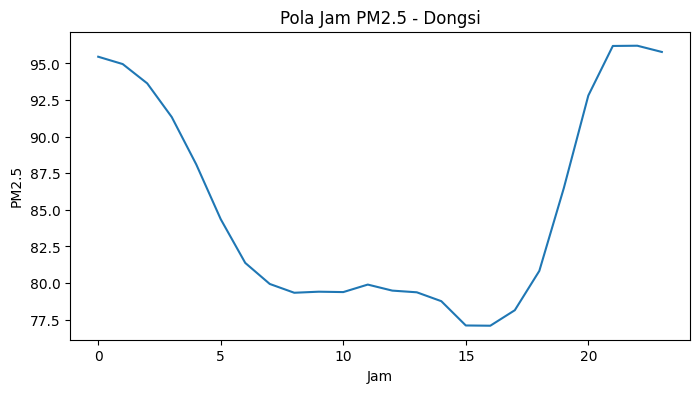

In [107]:
hourly = df_final[df_final['station']==top_station].groupby('hour')['PM2.5'].mean()

plt.figure(figsize=(8,4))
hourly.plot()
plt.title(f"Pola Jam PM2.5 - {top_station}")
plt.xlabel("Jam")
plt.ylabel("PM2.5")
plt.show()

**Insights:**
- PM2.5 di Dongsi tertinggi pada malam hingga dini hari (sekitar jam 21–01) dan menurun pada siang hari.
- Titik terendah terjadi sekitar jam 15–16 (~77), menunjukkan kualitas udara relatif lebih baik.
- Pola ini mengindikasikan akumulasi polusi pada malam hari dan dispersi lebih baik saat siang hari.

### Pertanyaan 4: Bagaimana tren rata-rata tahunan PM2.5, PM10, dan NO2 dari tahun 2013 hingga 2017 di seluruh stasiun?

<Figure size 1000x500 with 0 Axes>

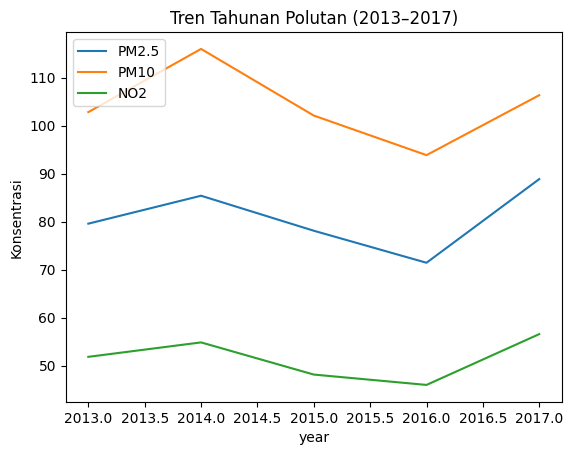

In [108]:
yearly = df_final.groupby('year')[['PM2.5','PM10','NO2']].mean()

plt.figure(figsize=(10,5))
yearly.plot()
plt.title("Tren Tahunan Polutan (2013–2017)")
plt.ylabel("Konsentrasi")
plt.show()

**Insights:**
- Polutan (PM2.5, PM10, NO2) cenderung menurun dari 2014 ke 2016, lalu kembali meningkat di 2017.
- Tahun 2014 menjadi puncak tertinggi, sementara 2016 titik terendah untuk semua polutan.
- Pola ini menunjukkan adanya perbaikan sementara kualitas udara, namun tidak konsisten hingga akhir periode.

### Pertanyaan 5: Stasiun mana yang menunjukkan penurunan PM2.5 paling signifikan antara tahun 2013 dan 2017?

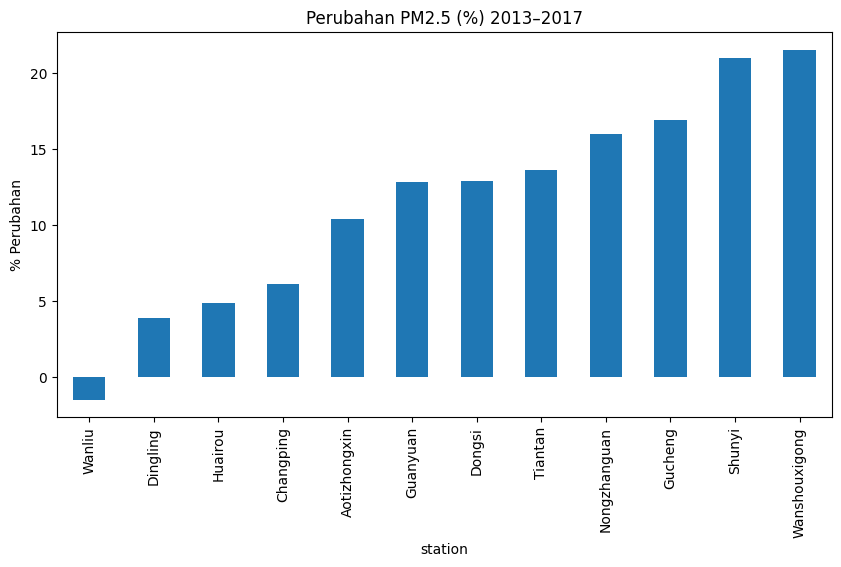

In [109]:
pm25_2013 = df_final[df_final['year']==2013].groupby('station')['PM2.5'].mean()
pm25_2017 = df_final[df_final['year']==2017].groupby('station')['PM2.5'].mean()

change = ((pm25_2017 - pm25_2013) / pm25_2013 * 100).sort_values()

plt.figure(figsize=(10,5))
change.plot(kind='bar')
plt.title("Perubahan PM2.5 (%) 2013–2017")
plt.ylabel("% Perubahan")
plt.show()

**Insights:**
- Polutan (PM2.5, PM10, NO2) cenderung menurun dari 2014 ke 2016, lalu kembali meningkat di 2017.
- Tahun 2014 menjadi puncak tertinggi, sementara 2016 titik terendah untuk semua polutan.
- Pola ini menunjukkan adanya perbaikan sementara kualitas udara, namun tidak konsisten hingga akhir periode.

### Pertanyaan 6: Faktor meteorologi mana (suhu, kecepatan angin, tekanan udara) yang memiliki korelasi paling kuat terhadap PM2.5 selama 2013–2017?

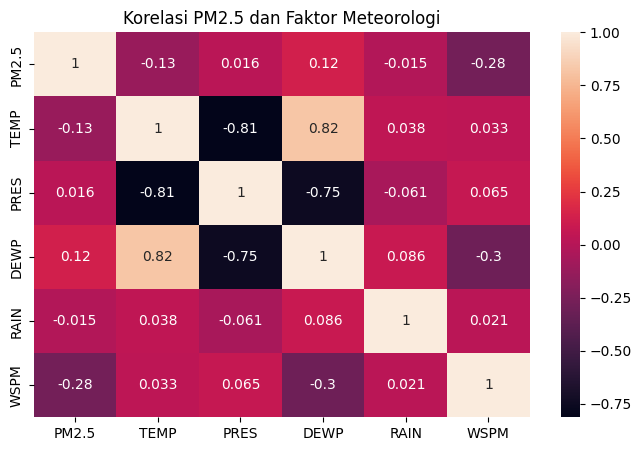

In [110]:
corr = df_final[['PM2.5','TEMP','PRES','DEWP','RAIN','WSPM']].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True)
plt.title("Korelasi PM2.5 dan Faktor Meteorologi")
plt.show()

**Insights:**
- Kecepatan Angin adalah Faktor Penentu Utama: WSPM (-0.28) memiliki korelasi negatif paling signifikan dibandingkan faktor lain. Ini menunjukkan bahwa ventilasi alami melalui angin adalah mekanisme pembersihan polutan yang paling efektif di atmosfer.

- Hubungan Berlawanan dengan Suhu: TEMP (-0.13) menunjukkan korelasi negatif yang lemah. Secara umum, saat suhu naik (siang hari), terjadi penguapan dan pergerakan udara vertikal yang sedikit membantu menurunkan konsentrasi PM2.5, meski pengaruhnya tidak sebesar angin.

- Tekanan Udara Hampir Tidak Berpengaruh Langsung: PRES (0.016) memiliki korelasi yang mendekati nol. Artinya, perubahan tekanan udara secara mandiri tidak bisa digunakan sebagai indikator naik-turunnya polusi PM2.5 tanpa mempertimbangkan faktor cuaca lainnya secara bersamaan.

### Pertanyaan 7: Pada bulan dan jam berapa PM2.5 mencapai level tertinggi sehingga menjadi prioritas waktu intervensi selama periode 2013–2017?

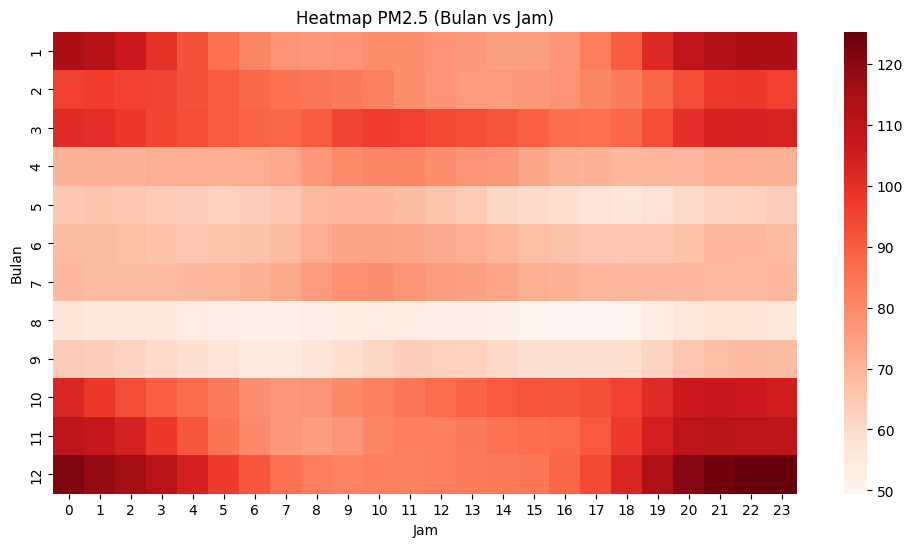

In [111]:
pivot = df_final.pivot_table(values='PM2.5', index='month', columns='hour', aggfunc='mean')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='Reds')
plt.title("Heatmap PM2.5 (Bulan vs Jam)")
plt.xlabel("Jam")
plt.ylabel("Bulan")
plt.show()

**Insights:**
- Puncak Musim Dingin (Desember-Januari): Konsentrasi polusi tertinggi terjadi secara konsisten pada akhir dan awal tahun. Intervensi khusus seperti pembatasan aktivitas industri berat atau penggunaan bahan bakar pemanas perlu diperketat pada bulan-bulan ini.

- Akumulasi Malam Hari (20:00 - 02:00): Terdapat pola peningkatan polusi yang tajam mulai pukul 8 malam. Hal ini kemungkinan disebabkan oleh inversi suhu (udara dingin terperangkap di bawah) dan berkurangnya aktivitas angin malam, sehingga polutan dari siang hari tidak terdispersi.

- Jendela "Relatif Aman" di Siang Hari: Kadar PM2.5 cenderung lebih rendah pada pukul 10:00 hingga 16:00 di hampir seluruh bulan (terlihat dari warna yang lebih terang). Ini menunjukkan bahwa pergerakan udara di siang hari jauh lebih baik dalam mengencerkan polutan dibandingkan malam hari.

## Analisis Lanjutan (Opsional)

### Analisis Kategori Arah Angin

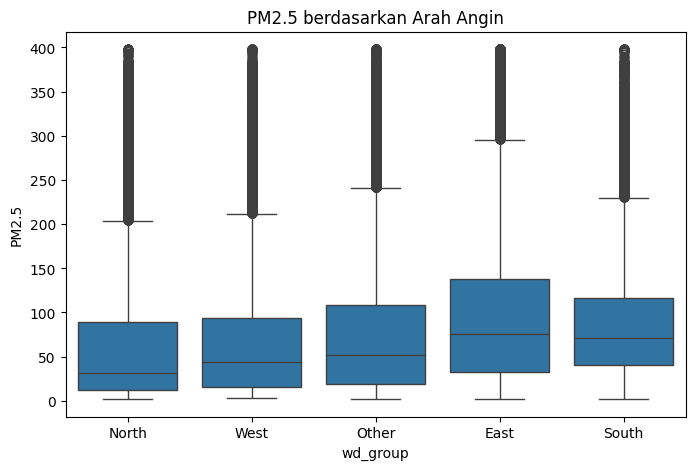

In [128]:
def categorize_wd(wd):
    if wd in ['N','NNE','NNW']:
        return 'North'
    elif wd in ['S','SSE','SSW']:
        return 'South'
    elif wd in ['E','ENE','ESE']:
        return 'East'
    elif wd in ['W','WNW','WSW']:
        return 'West'
    else:
        return 'Other'

df_final['wd_group'] = df_final['wd'].apply(categorize_wd)



plt.figure(figsize=(8,5))
sns.boxplot(data=df_final, x='wd_group', y='PM2.5')
plt.title("PM2.5 berdasarkan Arah Angin")
plt.show()

***Insights:***
- Angin Timur sebagai Pembawa Polutan Terbesar: Arah angin East (Timur) memiliki median nilai PM2.5 yang paling tinggi dan rentang interquartile yang paling lebar dibandingkan arah lainnya. Ini mengindikasikan bahwa sumber polusi utama kemungkinan besar berasal dari wilayah timur stasiun-stasiun tersebut.
- Angin Utara sebagai Pembersih Udara: Arah angin North (Utara) menunjukkan tingkat PM2.5 terendah (median paling kecil). Hal ini selaras dengan karakteristik geografis Beijing, di mana angin dari utara (dari arah pegunungan/Siberia) biasanya membawa udara yang lebih bersih dan kering.
- Anomali Outlier di Semua Arah: Terlepas dari arah anginnya, terdapat banyak titik outlier (titik hitam di atas kumis boxplot) yang mencapai angka 400. Ini menunjukkan bahwa pada kondisi ekstrem tertentu (seperti stagnasi udara),

## Clustering Station (K-MEANS)


In [122]:
from sklearn.cluster import KMeans

station_data = df_final.groupby('station')[['PM2.5','PM10','NO2']].mean()

kmeans = KMeans(n_clusters=3, random_state=42)
station_data['cluster'] = kmeans.fit_predict(station_data)

station_data

,PM2.5,PM10,NO2,cluster
station,,,,
Aotizhongxin,81.700338,109.141230,58.850242,0
Changping,70.311591,93.737021,44.009658,2
Dingling,66.217609,83.090199,27.089903,1
Dongsi,85.227516,109.184016,53.740949,0
Guanyuan,82.053006,108.291834,57.950905,0
Gucheng,83.061066,118.083204,55.613073,0
Huairou,68.800089,91.395274,31.878624,1
Nongzhanguan,84.221794,108.466863,57.888837,0
Shunyi,78.584916,98.117939,43.919924,2


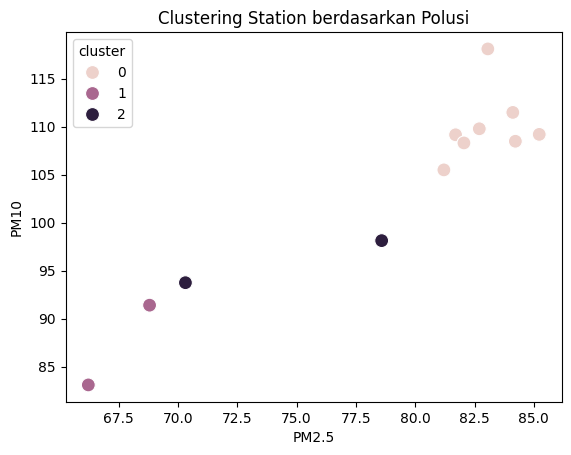

In [123]:
sns.scatterplot(data=station_data, x='PM2.5', y='PM10', hue='cluster', s=100)
plt.title("Clustering Station berdasarkan Polusi")
plt.show()

***Insights:***
- Dominasi Cluster 0 (Polusi Tinggi): Mayoritas stasiun (titik warna krem) berkumpul di sisi kanan atas, yang berarti stasiun-stasiun ini memiliki rata-rata PM2.5 (80–85) dan PM10 (105–115) yang sangat tinggi. Wilayah ini adalah area kritis yang membutuhkan kebijakan penanganan polusi yang seragam.
- Korelasi Linear PM2.5 dan PM10: Sebaran cluster membentuk pola garis diagonal yang konsisten. Artinya, di setiap stasiun, kenaikan PM2.5 hampir selalu diikuti oleh kenaikan PM10 dengan rasio yang stabil, menunjukkan bahwa sumber polutan keduanya kemungkinan besar sama (seperti pembakaran bahan bakar atau industri).
- Identifikasi Wilayah "Lebih Bersih": Stasiun di Cluster 1 (warna ungu tua) adalah wilayah dengan profil polusi paling rendah. Stasiun-stasiun ini bisa dijadikan referensi standar kualitas udara (benchmark) untuk melihat faktor apa yang membedakan mereka dari stasiun di Cluster 0.



### Deteksi Hari Polusi Ekstrem

In [125]:
threshold = df_final['PM2.5'].quantile(0.95)

extreme = df_final[df_final['PM2.5'] > threshold]

extreme_station = extreme['station'].value_counts()

extreme_station

,count
station,
Dongsi,2143
Nongzhanguan,2125
Wanshouxigong,2034
Aotizhongxin,1886
Gucheng,1880
Wanliu,1878
Guanyuan,1782
Tiantan,1780
Shunyi,1738


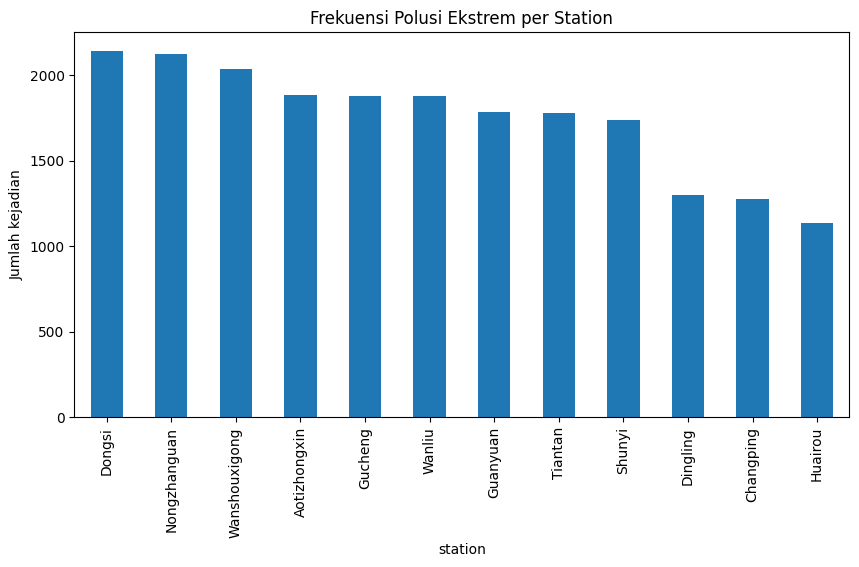

In [126]:
extreme_station.plot(kind='bar', figsize=(10,5))
plt.title("Frekuensi Polusi Ekstrem per Station")
plt.ylabel("Jumlah kejadian")
plt.show()

***Insights:***
- Dongsi dan Nongzhanguan Paling Rawan: Stasiun Dongsi dan Nongzhanguan mencatat frekuensi polusi ekstrem tertinggi (lebih dari 2000 kejadian). Hal ini menandakan area tersebut memiliki beban polusi yang paling berat atau letaknya sangat dekat dengan sumber emisi konstan.
- Kesenjangan Frekuensi antar Wilayah: Terdapat perbedaan signifikan antara wilayah pusat (Dongsi) dengan wilayah pinggiran seperti Huairou dan Changping yang memiliki jumlah kejadian ekstrem jauh lebih sedikit (hampir separuhnya). Ini menunjukkan adanya gradien spasial polusi dari pusat kota ke area rural.
- Prioritas Pengawasan Ketat: Tujuh stasiun pertama (dari Dongsi hingga Guanyuan) memiliki frekuensi kejadian ekstrem di atas 1750. Ketujuh wilayah ini harus menjadi prioritas utama untuk pemasangan sistem peringatan dini (early warning system) bagi masyarakat karena tingginya risiko terpapar udara berbahaya.

## Conclusion & Recommendation

- **Pertanyaan 1: Stasiun mana yang memiliki rata-rata tahunan PM2.5 tertinggi selama periode 2013–2017?**
  - **Conclusion:** Stasiun **Dongsi** mencatat rata-rata PM2.5 tahunan tertinggi, mengindikasikan tingkat polusi udara paling tinggi di antara stasiun-stasiun yang diamati. Stasiun-stasiun di area pinggiran seperti Dingling, Huairou, dan Changping cenderung memiliki kualitas udara yang lebih baik.

- **Pertanyaan 2: Bagaimana pola rata-rata bulanan PM2.5 di stasiun dengan polusi tertinggi selama periode 2013–2017?**
  - **Conclusion:** Di stasiun Dongsi, rata-rata bulanan PM2.5 menunjukkan pola musiman yang jelas, dengan konsentrasi tertinggi pada bulan Desember dan terendah pada bulan Agustus. Ini menunjukkan pengaruh cuaca dingin terhadap akumulasi polutan.

- **Pertanyaan 3: Pada jam berapa konsentrasi PM2.5 tertinggi terjadi dalam sehari di stasiun tersebut selama 2013–2017?**
  - **Conclusion:** Konsentrasi PM2.5 tertinggi di Dongsi terjadi pada malam hingga dini hari (sekitar pukul 21.00–01.00), dan menurun pada siang hari (sekitar pukul 15.00–16.00). Ini kemungkinan disebabkan oleh fenomena inversi suhu dan berkurangnya dispersi polutan pada malam hari.

- **Pertanyaan 4: Bagaimana tren rata-rata tahunan PM2.5, PM10, dan NO2 dari tahun 2013 hingga 2017 di seluruh stasiun?**
  - **Conclusion:** Tren rata-rata tahunan polutan PM2.5, PM10, dan NO2 secara keseluruhan menunjukkan penurunan dari tahun 2014 hingga 2016, namun kembali meningkat di tahun 2017. Tahun 2014 menjadi puncak polusi tertinggi dan 2016 menjadi titik terendah.

- **Pertanyaan 5: Stasiun mana yang menunjukkan penurunan PM2.5 paling signifikan antara tahun 2013 dan 2017?**
  - **Conclusion:** Stasiun **Wanliu** menunjukkan penurunan rata-rata PM2.5 paling signifikan antara tahun 2013 dan 2017. Sebaliknya, stasiun Wanshouxigong dan Shunyi menunjukkan peningkatan PM2.5 terbesar dalam periode yang sama.

- **Pertanyaan 6: Faktor meteorologi mana (suhu, kecepatan angin, tekanan udara) yang memiliki korelasi paling kuat terhadap PM2.5 selama 2013–2017?**
  - **Conclusion:** **Kecepatan angin (WSPM)** memiliki korelasi negatif paling kuat terhadap PM2.5 (-0.28), menunjukkan bahwa peningkatan kecepatan angin berkontribusi signifikan pada penurunan konsentrasi PM2.5. Suhu juga berkorelasi negatif tetapi lebih lemah, sedangkan tekanan udara memiliki korelasi yang sangat rendah.

- **Pertanyaan 7: Pada bulan dan jam berapa PM2.5 mencapai level tertinggi sehingga menjadi prioritas waktu intervensi selama periode 2013–2017?**
  - **Conclusion:** Level PM2.5 tertinggi secara konsisten terjadi pada bulan-bulan musim dingin (Desember dan Januari) dan pada jam-jam malam hingga dini hari (sekitar pukul 20.00–02.00). Periode ini menjadi prioritas utama untuk intervensi pengendalian polusi.


### Tambahan Insight dari Analisis Lanjutan:
- **Analisis Kategori Arah Angin:** Angin dari arah Timur (East) cenderung membawa konsentrasi PM2.5 tertinggi, sementara angin dari arah Utara (North) membawa udara yang lebih bersih.
- **Clustering Station (K-Means):** Stasiun-stasiun dapat dikelompokkan ke dalam kluster berdasarkan tingkat polusi, dengan mayoritas stasiun di pusat kota termasuk dalam kluster polusi tinggi (PM2.5: 80-85, PM10: 105-115).
- **Deteksi Hari Polusi Ekstrem:** Stasiun Dongsi dan Nongzhanguan memiliki frekuensi kejadian polusi ekstrem tertinggi, menunjukkan area ini sangat rentan terhadap kualitas udara yang buruk.

### Rekomendasi Action Item:
1.  **Fokus Intervensi pada Musim Dingin dan Malam Hari:** Prioritaskan kebijakan pengurangan emisi dan pembatasan aktivitas penyebab polusi, terutama pada bulan Desember-Januari dan antara pukul 20.00-02.00, karena periode ini menunjukkan konsentrasi PM2.5 tertinggi. Ini dapat mencakup pembatasan transportasi, pengoperasian industri, atau penggunaan pemanas rumah tangga.
2.  **Manfaatkan Data Arah Angin:** Perketat pengawasan dan terapkan langkah mitigasi polusi di wilayah yang menjadi sumber polutan ketika angin bertiup dari arah Timur. Pemasangan filter udara atau sistem pembersihan emisi di area sumber emisi di sebelah Timur stasiun dapat menjadi langkah efektif.
3.  **Implementasikan Sistem Peringatan Dini (EWS):** Kembangkan dan sebarkan EWS yang akurat, terutama untuk stasiun-stasiun dengan frekuensi polusi ekstrem tinggi seperti Dongsi dan Nongzhanguan. Informasi ini harus mudah diakses oleh publik agar mereka dapat mengambil tindakan pencegahan.
4.  **Inovasi Teknologi Reduksi Polusi:** Dorong penelitian dan pengembangan teknologi untuk mengurangi polutan PM2.5, PM10, dan NO2, khususnya di stasiun yang menunjukkan peningkatan polusi signifikan (misalnya, Wanshouxigong dan Shunyi).
5.  **Pengembangan Kebijakan Jangka Panjang:** Perhatikan tren tahunan yang menunjukkan fluktuasi dalam kualitas udara. Kebijakan harus adaptif dan berkelanjutan, tidak hanya reaktif terhadap lonjakan polusi, untuk mencapai perbaikan kualitas udara yang konsisten dan jangka panjang.